# Introducción a DEAP: Infraestructura Evolutiva en Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/05_algoritmos_geneticos/03_framework_deap_y_paralelizacion.ipynb)

## Objetivos


- Comprender la filosofía de diseño de DEAP (*Distributed Evolutionary Algorithms in Python*) y su arquitectura modular.
- Dominar los cuatro pilares del framework: `creator`, `toolbox`, `tools` y `algorithms`.
- Implementar infraestructura de monitoreo profesional utilizando `Logbook`, `Statistics` y `HallOfFame`.
- Aplicar criterios de ingeniería de software: paralelización de la evaluación de fitness y gestión de *Checkpoints* para tolerancia a fallos.



## Prerrequisitos


- Haber completado: [El Algoritmo Genético desde Cero](01_algoritmo_genetico_desde_cero.ipynb).
- Haber completado: [Exploración de Operadores y el Teorema "No Free Lunch"](02_operadores_y_benchmarks.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import pickle
import multiprocessing

# Instalación de DEAP, no está presente en Colab
try:
    import deap
except ImportError:
    !pip install deap
    import deap

from deap import base, creator, tools, algorithms

# Fijamos la semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 26.9 MB/s eta 0:00:00


## Introducción Teórica: La Filosofía de DEAP



En los notebooks anteriores, construimos un Algoritmo Genético (GA) desde cero. Aprendimos muchísimo, pero mantener ese código para problemas complejos de ingeniería es insostenible. Necesitamos un *framework*.

En el ecosistema de Python, librerías como `scikit-learn` nos acostumbran a usar "cajas negras" (`model.fit()`, `model.predict()`). **DEAP no funciona así.**

La filosofía de DEAP se basa en el zen de Python: *"Explícito es mejor que implícito"*. DEAP no te da un castillo armado; te da los bloques y los planos. Es necesario decidir cómo ensamblarlos. Esto lo hace increíblemente potente para la investigación y la resolución de problemas industriales no estándar.

> **Documentación Oficial:** A lo largo de este notebook, hacemos referencia a la [documentación oficial de DEAP](https://deap.readthedocs.io/en/master/). Es altamente recomendable tenerla a mano como material de consulta.

## Desarrollo e Implementación



Vamos a replicar exactamente el mismo problema que resolvimos en el Notebook [El Algoritmo Genético desde Cero](01_algoritmo_genetico_desde_cero.ipynb) (maximizar $f(x) = \left| \frac{\sin(x)}{x} \right|$), pero esta vez utilizando la arquitectura de DEAP.



### 1. Los Cuatro Pilares de DEAP



La arquitectura de DEAP se sostiene sobre cuatro módulos fundamentales.



#### Pilar 1: `creator` (Fábrica de Clases)


En un GA, necesitamos definir qué es un "Individuo" y qué es el "Fitness". Como esto cambia drásticamente de un problema a otro (¿es un *array* de *floats*? ¿una lista de enteros? ¿un árbol?), DEAP usa el módulo `creator` para generar estas clases dinámicamente en tiempo de ejecución.

In [2]:
# Limpiamos el creator por si ejecutamos esta celda múltiples veces
for cls in ['FitnessMax', 'Individual']:
    if hasattr(creator, cls):
        delattr(creator, cls)

# 1. Creamos la clase Fitness
# weights=(1.0,) indica MAXIMIZACIÓN. Si fuera minimización, usaríamos (-1.0,).
# IMPORTANTE: Siempre debe ser una tupla, incluso para un solo objetivo.
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Creamos la clase Individual
# Hereda de la clase estándar 'list' de Python, y le inyectamos el atributo 'fitness'
creator.create("Individual", list, fitness=creator.FitnessMax)

print("Clases creadas dinámicamente:")
print(f"Tipo de Fitness: {creator.FitnessMax}")
print(f"Tipo de Individuo: {creator.Individual}")

Clases creadas dinámicamente:
Tipo de Fitness: <class 'deap.creator.FitnessMax'>
Tipo de Individuo: <class 'deap.creator.Individual'>


#### Pilar 2: `toolbox` (Inyector de Dependencias)


El `toolbox` es una caja de herramientas donde registramos todas las funciones que nuestro algoritmo va a necesitar. Funciona creando "alias" de funciones existentes, pre-configurando algunos de sus parámetros.



In [3]:
toolbox = base.Toolbox()

# Definimos los límites de nuestro problema
X_MIN, X_MAX = -20.0, 20.0

# Registramos cómo generar un gen aleatorio
toolbox.register("attr_float", random.uniform, X_MIN, X_MAX)

# Registramos cómo generar un individuo (una lista de 1 gen)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=1)

# Registramos cómo generar una población (una lista de individuos)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Probamos nuestra caja de herramientas
ind_prueba = toolbox.individual()
pob_prueba = toolbox.population(n=3)

print(f"Individuo de prueba: {ind_prueba}")
print(f"Población de prueba (3 ind): {pob_prueba}")

Individuo de prueba: [5.577071938315349]
Población de prueba (3 ind): [[-18.99956979109332], [-8.99882726523523], [-11.071570474047089]]


#### Pilar 3 y 4: `tools` y `algorithms` (Operadores y Ciclo)


Ahora registramos los operadores evolutivos (cruce, mutación, selección y evaluación) utilizando las implementaciones optimizadas del módulo `tools`.



In [4]:
# 1. Función de Evaluación
def evaluar_funcion(individuo):
    """
    La función tiene muchos máximos locales.
    El máximo global se encuentra en: f(0) = 1
    """
    x = individuo[0]
    # Manejo seguro de la división por cero
    x_safe = np.where(x == 0, 1e-10, x)
    f = np.abs(np.sin(x_safe) / x_safe)

    # DEAP EXIGE que el fitness retornado sea una tupla
    return (f,)

toolbox.register("evaluate", evaluar_funcion)

# 2. Operadores Evolutivos
# Cruce Aritmético (Blend Crossover con alpha=0)
toolbox.register("mate", tools.cxBlend, alpha=0.0)

# Mutación Gaussiana
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1.0, indpb=1.0)

# Selección por Torneo
toolbox.register("select", tools.selTournament, tournsize=3)

# 3. Manejo de Restricciones (Clipping con Decoradores)
# En ingeniería, las variables físicas tienen límites (ej. una longitud no puede ser negativa).
# DEAP permite "decorar" los operadores para asegurar que los genes no salgan del dominio.
def limitar_dominio(func):
    """Decorador que asegura que los individuos resultantes estén dentro de [X_MIN, X_MAX]."""
    def wrapper(*args, **kwargs):
        # Ejecutamos el operador original (cruce o mutación)
        resultados = func(*args, **kwargs)
        # Aplicamos el clipping a cada individuo resultante
        for ind in resultados:
            ind[0] = max(X_MIN, min(X_MAX, ind[0]))
        return resultados
    return wrapper

# Aplicamos el decorador a los operadores que modifican los valores
toolbox.decorate("mate", limitar_dominio)
toolbox.decorate("mutate", limitar_dominio)

print("Toolbox configurado con manejo de restricciones (clipping) activado.")

Toolbox configurado con manejo de restricciones (clipping) activado.


### 1.1 Guía de Referencia: Elección de los Operadores Correctos (`tools`)

DEAP incluye docenas de operadores predefinidos. Elegir el operador incorrecto para el tipo de datos asociado al problema que intentamos resolver (ej. usar cruce aritmético en un problema de rutas) destruirá la validez de las soluciones.

Dejo una tabla de consulta rápida para cuando toque enfrentar un problema nuevo (machete para el futuro):

#### A. Operadores de Selección (`tools.sel...`)

La selección define la **presión selectiva**. Cuánta ventaja le damos a los mejores individuos frente a los peores.

| Operador | Descripción y Caso de Uso | Configuración Típica en DEAP |
| :--- | :--- | :--- |
| **`selTournament`** | **El estándar de la industria.** Balancea exploración y explotación ajustando el tamaño del torneo ($k$). Funciona con *fitness* negativo o positivo. | `tools.selTournament, tournsize=3` |
| **`selRoulette`** | Selección proporcional. **Peligro:** Causa convergencia prematura si hay un "súper-individuo". *Requiere que todo el fitness sea estrictamente positivo.* | `tools.selRoulette` |
| **`selBest` / `selWorst`** | Selección determinista pura. Se usa principalmente para aplicar **Elitismo** (salvar a los mejores) o para descartar a los peores. | `tools.selBest` |
| **`selNSGA2`** | Selección para **Optimización Multiobjetivo**. Usa dominancia de Pareto y *crowding distance*. (Lo vemos más adelante). | `tools.selNSGA2` |

#### B. Operadores de Cruce (`tools.cx...`)

El cruce depende 100% de la **codificación del cromosoma** (el genotipo).

| Tipo de Gen | Operador Recomendado | Descripción | Configuración Típica |
| :--- | :--- | :--- | :--- |
| **Reales (Continuos)** | **`cxBlend`** (BLX-$\alpha$) | Interpola valores entre los padres. Si $\alpha > 0$, permite explorar un poco más allá del segmento que los une. | `tools.cxBlend, alpha=0.5` |
| **Reales (Continuos)** | **`cxSimulatedBinaryBounded`** (SBX) | **Estándar en la industria para variables acotadas.** Simula el cruce de un punto binario pero en números reales. Respeta los límites físicos del problema. | `tools.cxSimulatedBinaryBounded, low=MIN, up=MAX, eta=20.0` |
| **Binarios / Categóricos** | **`cxTwoPoint`** | Intercambia un bloque de genes entre dos puntos de corte. Excelente para preservar "bloques" de características que funcionan bien juntas. | `tools.cxTwoPoint` |
| **Binarios / Categóricos** | **`cxUniform`** | Lanza una moneda por cada gen para decidir de qué padre lo hereda. Máxima mezcla genética. | `tools.cxUniform, indpb=0.5` |
| **Permutaciones (Rutas)** | **`cxOrdered`** (OX) | **Vital para TSP (Viajante de Comercio).** Preserva el orden relativo de las ciudades sin duplicar ni omitir ninguna. | `tools.cxOrdered` |

#### C. Operadores de Mutación (`tools.mut...`)

La mutación inyecta diversidad. Al igual que el cruce, depende del tipo de dato.

| Tipo de Gen | Operador Recomendado | Descripción | Configuración Típica |
| :--- | :--- | :--- | :--- |
| **Reales (Continuos)** | **`mutGaussian`** | Suma ruido blanco. Requiere aplicar *clipping* manual (como hicimos con nuestro decorador) para no salir del dominio. | `tools.mutGaussian, mu=0, sigma=1.0, indpb=0.1` |
| **Reales (Continuos)** | **`mutPolynomialBounded`** | **Estándar en la industria.** Mutación no uniforme que respeta estrictamente los límites `low` y `up`. | `tools.mutPolynomialBounded, low=MIN, up=MAX, eta=20.0, indpb=0.1` |
| **Binarios** | **`mutFlipBit`** | Invierte el bit (0 a 1, o 1 a 0) con una probabilidad dada. | `tools.mutFlipBit, indpb=0.1` |
| **Enteros** | **`mutUniformInt`** | Reemplaza el gen por un número entero aleatorio dentro de un rango. Útil para optimizar hiperparámetros (ej. `n_estimators`). | `tools.mutUniformInt, low=10, up=500, indpb=0.1` |
| **Permutaciones** | **`mutShuffleIndexes`** | Intercambia la posición de dos o más elementos en la secuencia. | `tools.mutShuffleIndexes, indpb=0.05` |

> 💡 **Criterio de Ingeniería:** La probabilidad `indpb` en las mutaciones se refiere a la probabilidad de que **cada gen individual** mute. Una regla de oro es setear `indpb = 1.0 / N_GENES`, lo que garantiza que, en promedio, mute exactamente un gen por individuo.

### 2. Infraestructura de Monitoreo


En los *notebooks* anteriores, creamos *arrays* de NumPy a mano para guardar el mejor *fitness* de cada generación. DEAP automatiza esto con tres herramientas, cada una con objetivos específicos:

1. **`Statistics`:** Calcula métricas (media, max, min, std) sobre la población en cada generación.
2. **`Logbook`:** Un registro tabular (similar a un DataFrame) que almacena las estadísticas.
3. **`HallOfFame`:** Una "memoria histórica" que guarda a los $N$ mejores individuos que han existido en toda la evolución, incluso si murieron en generaciones posteriores.

In [5]:
# Configuramos las estadísticas
stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats.register("max", np.max)
stats.register("mean", np.mean)
stats.register("std", np.std)

# Configuramos el Salón de la Fama (guardamos al mejor individuo histórico)
hof = tools.HallOfFame(maxsize=1)

### 3. Ejecución del Algoritmo y el Ecosistema `algorithms`


DEAP provee varios algoritmos listos para usar en su módulo `algorithms`. Antes de ejecutar nuestro código, es bueno conocer qué opciones tenemos para el futuro:
*   `eaSimple`: El Algoritmo Genético canónico (el que usamos ahora).
*   `eaMuPlusLambda`: Estrategia $(\mu + \lambda)$. Los padres y los hijos compiten juntos. Garantiza elitismo estricto. (Lo vemos en el notebook siguiente).
*   `eaMuCommaLambda`: Estrategia $(\mu, \lambda)$. Solo los hijos compiten. Útil para entornos dinámicos o ruidosos.
*   `eaGenerateUpdate`: Plantilla genérica utilizada para algoritmos como *Particle Swarm Optimization* (PSO).

Ejecutamos nuestro problema usando `eaSimple` con los hiperparámetros ajustados para la función *sinc*.

In [6]:
# Hiperparámetros
N_POP = 10
N_GEN = 20
CXPB = 0.85  # Probabilidad de cruce
MUTPB = 0.10 # Probabilidad de mutación

# Inicializamos la población
poblacion = toolbox.population(n=N_POP)

# Ejecutamos el algoritmo
poblacion_final, logbook = algorithms.eaSimple(
    population=poblacion,
    toolbox=toolbox,
    cxpb=CXPB,
    mutpb=MUTPB,
    ngen=N_GEN,
    stats=stats,
    halloffame=hof,
    verbose=True # True para ver la tabla de progreso
)

gen	nevals	max    	mean    	std     
0  	10    	0.99237	0.128124	0.290126
1  	8     	0.206416	0.100303	0.0618943
2  	10    	0.996775	0.430482	0.326729 
3  	5     	0.999902	0.801452	0.345594 
4  	8     	0.999791	0.879502	0.263748 
5  	9     	0.99974 	0.987443	0.0218394
6  	7     	0.99974 	0.99556 	0.0117188
7  	6     	0.99974 	0.99974 	2.22045e-16
8  	7     	0.99974 	0.923964	0.157516   
9  	10    	0.99974 	0.944578	0.157971   
10 	8     	0.99974 	0.996833	0.00718464 
11 	8     	0.99974 	0.99974 	2.22045e-16
12 	8     	0.99974 	0.99974 	2.22045e-16
13 	10    	0.99974 	0.99974 	2.22045e-16
14 	10    	0.99974 	0.997775	0.00589553 
15 	6     	0.99974 	0.973249	0.0794741  
16 	8     	0.99974 	0.997484	0.00676789 
17 	8     	0.99974 	0.961598	0.104285   
18 	4     	0.99974 	0.99974 	2.22045e-16
19 	8     	0.99974 	0.988289	0.0343534  
20 	10    	0.99974 	0.998409	0.00399317 


Mejor individuo encontrado: x = -0.0243
Fitness alcanzado: 0.9999


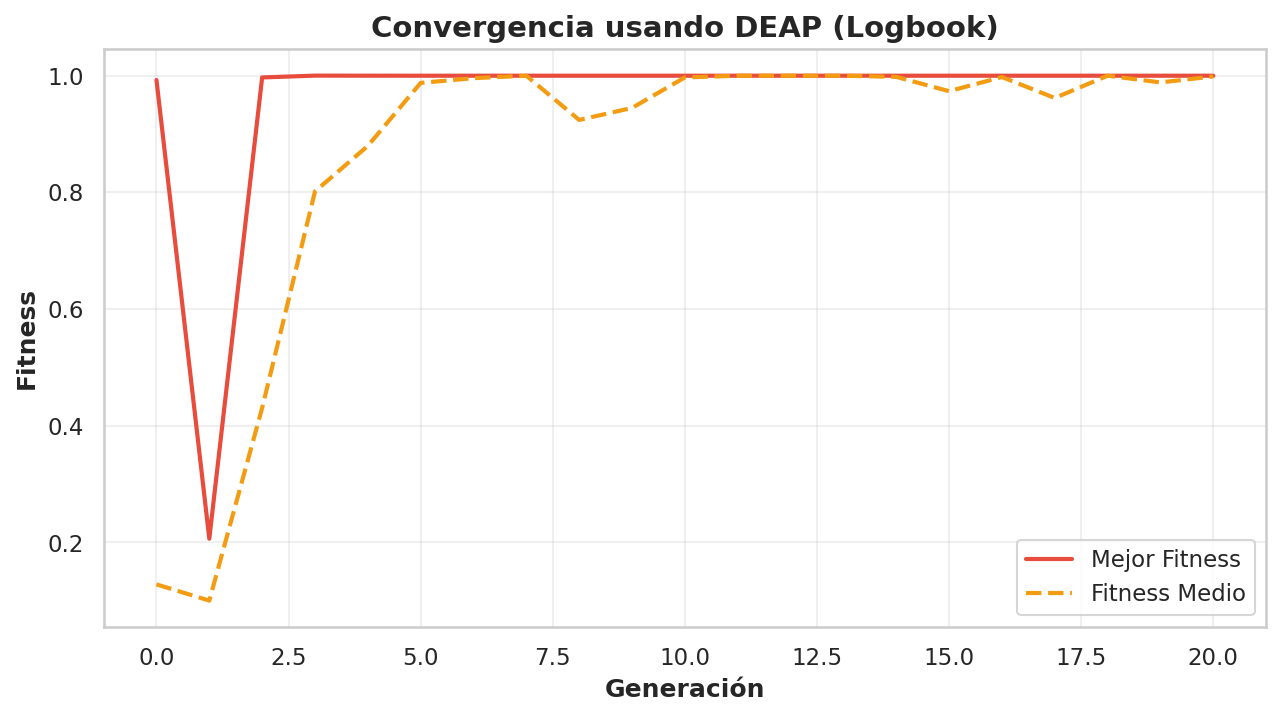

In [7]:
# Extraemos resultados
mejor_individuo = hof[0]
print(f"Mejor individuo encontrado: x = {mejor_individuo[0]:.4f}")
print(f"Fitness alcanzado: {mejor_individuo.fitness.values[0]:.4f}")

# Extraemos datos del Logbook para graficar
generaciones = logbook.select("gen")
max_fitness = logbook.select("max")
mean_fitness = logbook.select("mean")

plt.figure(figsize=(10, 5))
plt.plot(generaciones, max_fitness, label='Mejor Fitness', color='#e74c3c', lw=2)
plt.plot(generaciones, mean_fitness, label='Fitness Medio', color='#f39c12', linestyle='--', lw=2)
plt.title("Convergencia usando DEAP (Logbook)")
plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Ingeniería de Software I: Paralelización


En problemas académicos, evaluar la función $f(x)$ toma microsegundos. Pero en ingeniería real, la función de *fitness* podría ser una simulación de fluidos (CFD) o el entrenamiento de un modelo de Machine Learning que toma varios segundos.

Si tenemos 100 individuos y 50 generaciones, son 5.000 evaluaciones. Si cada una toma 1 segundo, el algoritmo tardará casi **1,5 horas** de forma secuencial.

DEAP permite paralelizar la evaluación inyectando el método `map` de la librería `multiprocessing` directamente en el `toolbox`. Vamos a simular esto añadiendo un retraso artificial a nuestra función *sinc* y ejecutando `eaSimple` en paralelo.

In [8]:
# Simulamos una función de fitness "pesada" que tarda 10 milisegundos
def evaluar_pesado(individuo):
    time.sleep(0.01)
    return evaluar_funcion(individuo)

toolbox.register("evaluate_pesado", evaluar_pesado)

# 1. Ejecución Secuencial
print("Iniciando evaluación secuencial...")
pob_secuencial = toolbox.population(n=N_POP)
inicio = time.time()
# Usamos el map estándar de Python
list(map(toolbox.evaluate_pesado, pob_secuencial))
tiempo_secuencial = time.time() - inicio
print(f"Tiempo Secuencial: {tiempo_secuencial:.2f} segundos")

# 2. Ejecución Paralela
print("\nIniciando evaluación paralela...")
# Nota: En Windows/Jupyter, el multiprocessing a veces requiere estar dentro de un bloque if __name__ == '__main__':
# En Colab/Linux funciona nativamente.
try:
    pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())

    # ¡Esta es la línea mágica de DEAP! Reemplazamos el 'map' estándar por el 'map' del Pool
    toolbox.register("map", pool.map)

    pob_paralela = toolbox.population(n=N_POP)
    inicio = time.time()

    # Ejecutamos eaSimple. Internamente usará el pool.map que acabamos de registrar
    algorithms.eaSimple(pob_paralela, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=5, verbose=False)

    tiempo_paralelo = time.time() - inicio

    pool.close()
    pool.join()

    print(f"Tiempo Paralelo (5 generaciones): {tiempo_paralelo:.2f} segundos")
    print(f"Aceleración (Speedup): {tiempo_secuencial / tiempo_paralelo:.2f}x")

    # Restauramos el map original para el resto del notebook
    toolbox.register("map", map)
except Exception as e:
    print(f"La paralelización falló en este entorno: {e}")

Iniciando evaluación secuencial...
Tiempo Secuencial: 0.10 segundos

Iniciando evaluación paralela...
Tiempo Paralelo (5 generaciones): 0.03 segundos
Aceleración (Speedup): 3.67x



> 💡 **Criterio de Ingeniería:** La paralelización tiene un *overhead* (tiempo de creación de procesos y copia de memoria). Si la función de *fitness* es extremadamente rápida (microsegundos), la versión paralela será **más lenta** que la secuencial. Solo paralelizar cuando el costo de evaluación justifique el *overhead*.


## Ingeniería de Software II: Bucle Manual y Checkpoints (Tolerancia a Fallos)


Si el algoritmo va a correr durante 3 días en un servidor en la nube, existe el riesgo de que el servidor se reinicie. Si estamos en local, se puede cortar la energía o se acaba la memoria RAM. Si eso pasa en la generación 499 de 500, se perdería todo el trabajo. La solución es implementar **Checkpoints**: guardar el estado completo de la evolución en el disco duro cada $N$ generaciones. *Igual que con deep learning...*


### Checkpoints

Guardamos el estado completo de la evolución (población, logbook, hall of fame y número de generación) en el disco duro cada $N$ generaciones usando la librería `pickle`. A continuación, funciones para guardado y carga de los checkpoints.

In [9]:
# Archivo donde guardamos el estado
CHECKPOINT_FILE = "checkpoint_ga.pkl"

def guardar_checkpoint(poblacion, generacion, logbook, hof):
    estado = {
        "poblacion": poblacion,
        "generacion": generacion,
        "logbook": logbook,
        "hof": hof,
        "rng_state": random.getstate() # Guardamos el estado del generador aleatorio
    }
    with open(CHECKPOINT_FILE, "wb") as f:
        pickle.dump(estado, f)
    print(f"💾 Checkpoint guardado en la generación {generacion}")

def cargar_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, "rb") as f:
            estado = pickle.load(f)
        random.setstate(estado["rng_state"])
        print(f"🔄 Checkpoint cargado. Reanudando desde la generación {estado['generacion']}")
        return estado["poblacion"], estado["generacion"], estado["logbook"], estado["hof"]
    return None, 0, tools.Logbook(), tools.HallOfFame(maxsize=1)

### Bucle Manual en DEAP


El algoritmo `algorithms.eaSimple` es fantástico, pero es una caja cerrada. No tiene un mecanismo nativo para guardar *checkpoints* a mitad de camino ni para implementar **Early Stopping** (detener el algoritmo si ya no mejora).

Para lograr esto, debemos **escribir el bucle evolutivo a mano**, pero aprovechando las herramientas del `toolbox` de DEAP. Esta es la plantilla que se usaría en proyectos reales.

In [10]:
# Restauramos la función de evaluación rápida
toolbox.register("evaluate", evaluar_funcion)

# Intentamos cargar un checkpoint previo, si no, inicializamos desde cero
pob, gen_inicial, logbook_manual, hof_manual = cargar_checkpoint()
if pob is None:
    pob = toolbox.population(n=50)

    # Evaluamos la población inicial
    fitnesses = list(map(toolbox.evaluate, pob))
    for ind, fit in zip(pob, fitnesses):
        ind.fitness.values = fit
    hof_manual.update(pob)

# Parámetros de Early Stopping
PACIENCIA = 15
N_GEN = 100
generaciones_sin_mejora = 0
mejor_fitness_historico = hof_manual[0].fitness.values[0] if len(hof_manual) > 0 else -np.inf

print("\nIniciando Bucle Manual con Early Stopping y Checkpoints...")

for gen in range(gen_inicial + 1, N_GEN + 1):
    # 1. Selección
    offspring = toolbox.select(pob, len(pob))
    # Clonamos a los individuos para no modificar a los padres por referencia
    offspring = list(map(toolbox.clone, offspring))

    # 2. Cruce
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    # 3. Mutación
    for mutant in offspring:
        if random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # 4. Evaluación de individuos inválidos (los que fueron cruzados o mutados)
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # 5. Reemplazo
    pob[:] = offspring
    hof_manual.update(pob)

    # 6. Monitoreo y Checkpoints
    record = stats.compile(pob)
    logbook_manual.record(gen=gen, evals=len(invalid_ind), **record)

    if gen % 2 == 0:    # Hardcodeado acá, a modo de ejemplo. Cada 2 generaciones se guarda
        guardar_checkpoint(pob, gen, logbook_manual, hof_manual)

    # 7. Lógica de Early Stopping
    fitness_actual = hof_manual[0].fitness.values[0]
    if fitness_actual > mejor_fitness_historico + 1e-5:
        mejor_fitness_historico = fitness_actual
        generaciones_sin_mejora = 0
    else:
        generaciones_sin_mejora += 1

    if generaciones_sin_mejora >= PACIENCIA:
        print(f"🛑 Early Stopping activado en la generación {gen}. El fitness no ha mejorado en {PACIENCIA} generaciones.")
        break

print(f"\nEvolución finalizada. Mejor fitness: {hof_manual[0].fitness.values[0]:.4f}")

# Limpieza del archivo de checkpoint para futuras ejecuciones
# if os.path.exists(CHECKPOINT_FILE):
#     os.remove(CHECKPOINT_FILE)


Iniciando Bucle Manual con Early Stopping y Checkpoints...
💾 Checkpoint guardado en la generación 2
💾 Checkpoint guardado en la generación 4
💾 Checkpoint guardado en la generación 6
💾 Checkpoint guardado en la generación 8
💾 Checkpoint guardado en la generación 10
💾 Checkpoint guardado en la generación 12
💾 Checkpoint guardado en la generación 14
💾 Checkpoint guardado en la generación 16
💾 Checkpoint guardado en la generación 18
💾 Checkpoint guardado en la generación 20
🛑 Early Stopping activado en la generación 20. El fitness no ha mejorado en 15 generaciones.

Evolución finalizada. Mejor fitness: 1.0000


Por supuesto, todo esto se puede "empaquetar" en una función o clase más elegante. Y generar un algoritmo personalizado, equivalente a los disponibles en el módulo `algorithms`.

## Resultados y Discusión


En este notebook dimos un salto cualitativo enorme.


Al utilizar DEAP:
1. **Redujimos el código repetitivo (Boilerplate):** No tenemos que reescribir la lógica de selección por torneo o cruce aritmético.
2. **Ganamos Escalabilidad:** Con una sola línea (`toolbox.register("map", pool.map)`), nuestro algoritmo puede ejecutarse en un clúster de 64 núcleos.
3. **Ganamos Robustez:** Al entender cómo escribir el bucle manual, podemos inyectar lógica de negocio compleja (como *Early Stopping* o *Checkpoints*) sin perder las ventajas de los operadores optimizados de DEAP.

## Conexiones y Próximos Pasos



Hasta ahora, trabajamos exclusivamente en **espacios continuos** (donde los genes son números reales). Pero, ¿qué pasa si queremos optimizar la ruta de un camión de reparto (donde los genes son ciudades y no se pueden repetir)? ¿O si queremos asignar turnos a enfermeras (donde los genes son variables binarias)?

En el próximo notebook, abandonamos la matemática continua y adaptamos nuestro framework DEAP para resolver problemas de **Optimización Combinatoria**.

- ➡️ **Siguiente:** [Optimización Combinatoria: Espacios Discretos y Permutaciones](04_optimizacion_combinatoria.ipynb)
- 🔄 **Relacionado:** [Exploración de Operadores y el Teorema "No Free Lunch"](02_operadores_y_benchmarks.ipynb)



## Referencias


1. **Fortin, F. A., De Rainville, F. M., Gardner, M. A., Parizeau, M., & Gagné, C. (2012).** *DEAP: Evolutionary algorithms made easy*. Journal of Machine Learning Research, 13(Jul), 2171-2175.
2. [Documentación Oficial de DEAP](https://deap.readthedocs.io/en/master/)

---


## Entorno de Ejecución


In [11]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
backcall,0.2.0
bottleneck,1.4.2
certifi,2026.5.20
